# Klassifikation und Feature Engineering mit Python und Scikit-Learn

## Simulation der Daten

In diesem Fall simulieren wir Daten, um die Klassifikation und das Feature Engineering zu demonstrieren. Hierzu generieren wir uns zwei Typen von EKG-Signalen

![](images/ECG_principle_slow.gif)

In [124]:
# Load NeuroKit and other useful packages
# Install NeuroKit with pip install neurokit2 in notebook: pip install neurokit2

import neurokit2 as nk
import numpy as np
import pandas as pd
import seaborn as sns

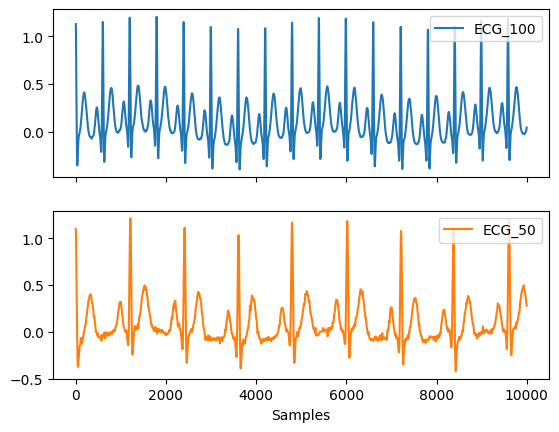

In [125]:
# Alternate heart rate and noise levels
ecg50 = nk.ecg_simulate(duration=10, noise=0.05, heart_rate=50)
ecg100 = nk.ecg_simulate(duration=10, noise=0.01, heart_rate=100)

# Visualize
ecg_df = pd.DataFrame({"ECG_100": ecg100, "ECG_50": ecg50})

nk.signal_plot(ecg_df, subplots=True)

### Simulieren von EKG-Signalen

Wir simulieren uns ein Datenset mit je 100 Ruhe-EKG und Belastungs-EKG Signalen. Hierzu verwenden wir die Funktion `ecg_simulator` aus dem Modul `ecg_simulator.py`. Die Funktion generiert uns ein EKG-Signal mit einer zufällig verteilten Frequenz und einer festen Anzahl an Samples.

In [126]:
data = {}

typ = "Ruhe EKG"
for i in range(100):
    heart_rate = np.random.normal(70, 35)
    # Ensure heart rate is positive
    if heart_rate < 40:
        heart_rate = 40
    data[i] = {}
    data[i]["EGK"] = nk.ecg_simulate(duration=10, noise=0.1, heart_rate=heart_rate)
    data[i]["Type"] = typ
print(i)


typ = "Belastung EKG"
for i in range(100,200):
    heart_rate = np.random.normal(140, 60)
    if heart_rate < 40:
        heart_rate = 40
    data[i] = {}
    data[i]["EGK"] = nk.ecg_simulate(duration=10, noise=0.1, heart_rate=heart_rate)
    data[i]["Type"] = typ
print(i)

99
199


## Daten visualisieren

Als erstes werden wir die Daten visualisieren, um einen besseren Eindruck von den Daten zu bekommen. Hierzu plotten wird uns Beispielhaft ein Ruhe-EKG und ein Belastungs-EKG Signal und vergleichen die Mittelwerte und Standardabweichungen der beiden Signale.

In [127]:
data[0]

{'EGK': array([1.04524038, 1.04217524, 1.03565682, ..., 0.15013292, 0.14836052,
        0.14776172]),
 'Type': 'Ruhe EKG'}

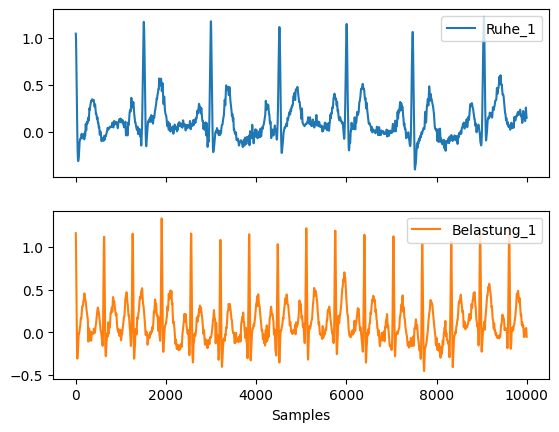

In [128]:
# Visualize
ecg_df = pd.DataFrame({"Ruhe_1": data[0]["EGK"], "Belastung_1": data[100]["EGK"]})

nk.signal_plot(ecg_df, subplots=True)

In [129]:
## make a dataframe with the mean and standard deviation of the ECG signals

df = pd.DataFrame(data).T
df["Mean"] = df["EGK"].apply(np.mean)
df["STD"] = df["EGK"].apply(np.std)
df.head()

,EGK,Type,Mean,STD
0,"[1.0452403821099394, 1.0421752447207282, 1.035...",Ruhe EKG,0.121633,0.210865
1,"[1.1629829249380186, 1.1581694812787546, 1.146...",Ruhe EKG,0.140646,0.260412
2,"[1.128605448621482, 1.123413075442241, 1.11117...",Ruhe EKG,0.088686,0.239190
3,"[1.043730302149139, 1.0407825337096603, 1.0347...",Ruhe EKG,0.078706,0.217442
4,"[1.1321287758838947, 1.125699107133572, 1.1098...",Ruhe EKG,0.203906,0.226710


<Axes: xlabel='Type', ylabel='Mean'>

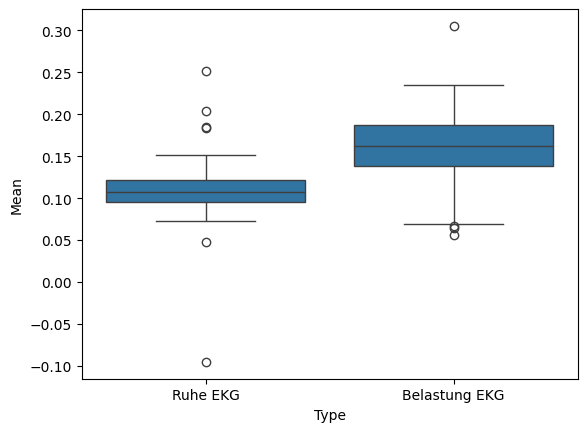

In [130]:
# make a boxplot of the mean of the ECG signals

sns.boxplot(x="Type", y="Mean", data=df)

<Axes: xlabel='Type', ylabel='STD'>

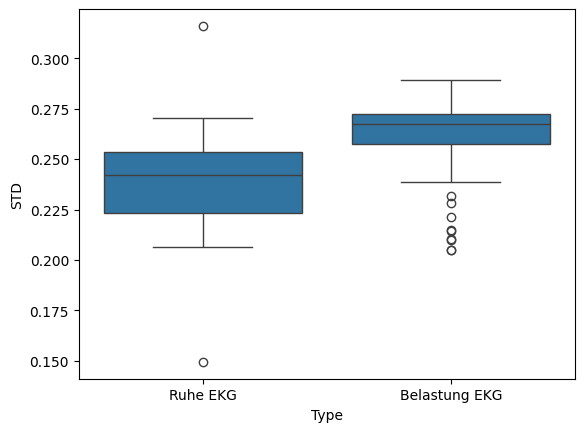

In [131]:
# make a boxplot of the mean of the ECG signals

sns.boxplot(x="Type", y="STD", data=df)

Offensichtlich sind die beiden Signale sehr unterschiedlich. Das einzelne Ruhe-EKG Signal hat einen geringeren Mittelwert und eine geringere Standardabweichung als das Belastungs-EKG Signal.

## Feature Engineering

Hiermit haben wir bereits den ersten Schritt im Feature Engineering gemacht und können `Mean` und `STD` als Features verwenden.

In [132]:
df.head()

,EGK,Type,Mean,STD
0,"[1.0452403821099394, 1.0421752447207282, 1.035...",Ruhe EKG,0.121633,0.210865
1,"[1.1629829249380186, 1.1581694812787546, 1.146...",Ruhe EKG,0.140646,0.260412
2,"[1.128605448621482, 1.123413075442241, 1.11117...",Ruhe EKG,0.088686,0.239190
3,"[1.043730302149139, 1.0407825337096603, 1.0347...",Ruhe EKG,0.078706,0.217442
4,"[1.1321287758838947, 1.125699107133572, 1.1098...",Ruhe EKG,0.203906,0.226710


In [133]:
### Fourier Transform

# Add colums for different frequencies

for i in range(1, 100):
    df[f"Freq_{i}"] = df["EGK"].apply(lambda x: np.abs(np.fft.fft(x))[i])
df.head()


C:\Users\jlhuber\AppData\Local\Temp\ipykernel_10592\1492508150.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"Freq_{i}"] = df["EGK"].apply(lambda x: np.abs(np.fft.fft(x))[i])
C:\Users\jlhuber\AppData\Local\Temp\ipykernel_10592\1492508150.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"Freq_{i}"] = df["EGK"].apply(lambda x: np.abs(np.fft.fft(x))[i])


,EGK,Type,Mean,STD,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,...,Freq_90,Freq_91,Freq_92,Freq_93,Freq_94,Freq_95,Freq_96,Freq_97,Freq_98,Freq_99
0,"[1.0452403821099394, 1.0421752447207282, 1.035...",Ruhe EKG,0.121633,0.210865,61.759720,195.258097,283.019683,203.320485,184.854291,249.325614,...,23.909104,54.612808,23.848267,135.901525,163.263182,105.972713,90.613948,30.886371,25.491964,91.994923
1,"[1.1629829249380186, 1.1581694812787546, 1.146...",Ruhe EKG,0.140646,0.260412,39.365567,233.735586,289.788225,58.544874,36.466908,68.578035,...,48.064212,603.504076,50.700425,68.503268,81.919685,7.725875,14.660097,25.843257,7.106331,22.914575
2,"[1.128605448621482, 1.123413075442241, 1.11117...",Ruhe EKG,0.088686,0.239190,136.004201,168.234805,166.346702,61.612084,104.851645,67.380281,...,127.121069,88.634624,63.013574,324.722677,27.776219,82.082475,146.297379,51.178888,18.897645,82.055191
3,"[1.043730302149139, 1.0407825337096603, 1.0347...",Ruhe EKG,0.078706,0.217442,86.360026,195.921407,314.221805,134.447659,141.455721,210.643755,...,56.723068,95.960927,71.230662,192.865908,13.227622,140.464750,81.638067,93.502919,21.763904,16.378166
4,"[1.1321287758838947, 1.125699107133572, 1.1098...",Ruhe EKG,0.203906,0.226710,214.841635,109.638119,183.538773,125.544905,68.498290,96.904312,...,111.711328,54.459781,48.587835,40.572718,23.262292,34.000325,31.949804,20.076034,4.794255,18.455169


Durch eine Visualisierung der Daten können wir evaluieren, ob die Frequenz des Signals ein weiteres Feature sein könnte. Hierzu plotten wir die Frequenz der Signale und vergleichen die beiden Klassen z.B. Belastungs-EKG (100 und 101) und Ruhe-EKG (0,1).

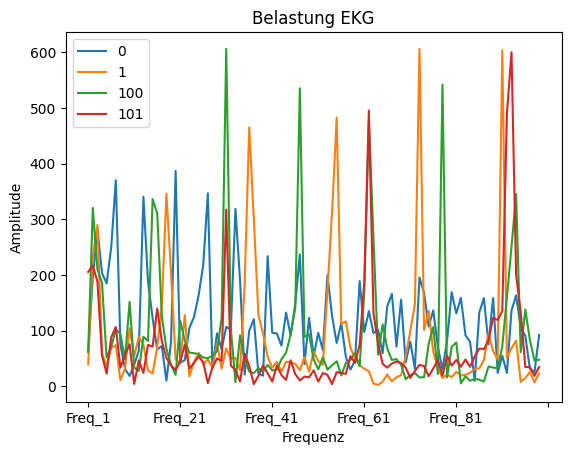

In [134]:
# Make a plot for the Frequencies of the first ECG signal

for id in [0,1,100,101]:

    plt = df.iloc[id, 4:].plot()
    plt.set_title(df.iloc[id, 1])
    plt.set_xlabel("Frequenz")
    plt.set_ylabel("Amplitude")
    plt.legend()


Offensichtlich, sind hier keine eindeutigen Unterschiede zu erkennen. Daher versuchen wir noch einmal die Mittelwerte der einzelnen Frequenzen der Beiden EKG-Signale zu vergleichen.

In [135]:
# Melt the DataFrame so that we have a column for the type and the frequency

df_melted = pd.melt(df, id_vars=["Type"], value_vars=df.columns[4:])
df_melted.head()

,Type,variable,value
0,Ruhe EKG,Freq_1,61.759720
1,Ruhe EKG,Freq_1,39.365567
2,Ruhe EKG,Freq_1,136.004201
3,Ruhe EKG,Freq_1,86.360026
4,Ruhe EKG,Freq_1,214.841635


<Axes: xlabel='variable', ylabel='value'>

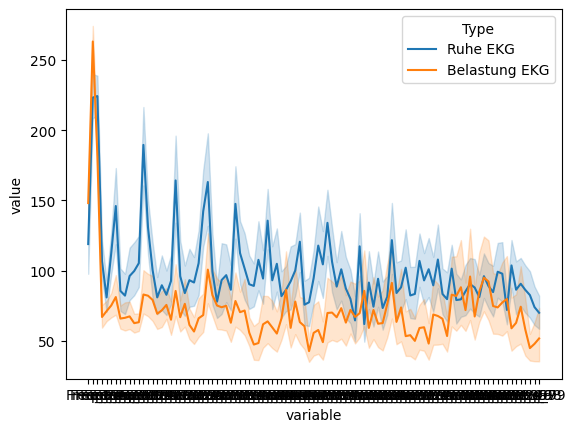

In [136]:
# plot the frequencies grouped by type

sns.lineplot(x="variable", y="value", hue="Type", data=df_melted)


Auch hier wird deutlich, dass es keine einzelne Frequenz gibt, die die beiden Klassen trennt. Entsprechend müssen wir überlegen, ob wir die Frequenz als Feature verwenden wollen.

## Aufteilen der Daten

Als nächstes teilen wir die Daten in Trainings- und Testdaten auf. Wir verwenden 80% der Daten für das Training und 20% für das Testen.


In [137]:
y = df['Type']
# X = df.drop(['Type','EGK'], axis=1)
X = df[['Mean', 'STD']]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,Mean,STD
79,0.112986,0.231869
197,0.170264,0.276500
38,0.097769,0.244209
24,0.080153,0.218025
122,0.109447,0.248534


**Hinweis**

Für mache Modelle müssen wir ggf. die Type Variable in numerische Werte umwandeln. Hierzu können wir die Funktion `get_dummies` aus dem Modul `pandas` verwenden.

```python
df = pd.get_dummies(df, columns=['Type'])
```

## Trainieren des Modells

Als nächstes trainieren wir das Modell mit den Trainingsdaten und können uns auch die Koeffizienten der Linearen Regression ausgeben lassen.

In [138]:
import numpy as np
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

model.coef_

array([[-1.89044187, -0.84492685]])

Die können wir wie folgt interpretieren:

$\text{petal.length} = +0.72281463 -0.63581649 \cdot \text{sepal.length} + 1.46752403 \cdot \text{sepal.width}$

Wir können diese Formel verwenden, um die Petal Length für neue Daten vorherzusagen.

In [139]:
y_pred = model.predict(X_train)

y_pred

array(['Ruhe EKG', 'Belastung EKG', 'Ruhe EKG', 'Ruhe EKG', 'Ruhe EKG',
       'Belastung EKG', 'Ruhe EKG', 'Belastung EKG', 'Belastung EKG',
       'Ruhe EKG', 'Belastung EKG', 'Ruhe EKG', 'Ruhe EKG',
       'Belastung EKG', 'Belastung EKG', 'Ruhe EKG', 'Belastung EKG',
       'Ruhe EKG', 'Belastung EKG', 'Belastung EKG', 'Belastung EKG',
       'Ruhe EKG', 'Ruhe EKG', 'Belastung EKG', 'Belastung EKG',
       'Belastung EKG', 'Ruhe EKG', 'Belastung EKG', 'Ruhe EKG',
       'Belastung EKG', 'Ruhe EKG', 'Belastung EKG', 'Belastung EKG',
       'Ruhe EKG', 'Belastung EKG', 'Ruhe EKG', 'Belastung EKG',
       'Ruhe EKG', 'Belastung EKG', 'Belastung EKG', 'Ruhe EKG',
       'Belastung EKG', 'Ruhe EKG', 'Belastung EKG', 'Belastung EKG',
       'Ruhe EKG', 'Belastung EKG', 'Belastung EKG', 'Belastung EKG',
       'Belastung EKG', 'Belastung EKG', 'Belastung EKG', 'Belastung EKG',
       'Belastung EKG', 'Ruhe EKG', 'Belastung EKG', 'Belastung EKG',
       'Ruhe EKG', 'Ruhe EKG', 'Belastung E

Für ein besseres Verständnis können wir die Daten nun in einen Datensatz zusammenfassen und die wahren Werte `Actual` mit den vorhergesagten Werten `Predicted` vergleichen.

In [140]:
df_result = pd.DataFrame({'Actual': y_train, 'Predicted': y_pred})
df_result.merge(X_train, left_index=True, right_index=True)

df_result


,Actual,Predicted
79,Ruhe EKG,Ruhe EKG
197,Belastung EKG,Belastung EKG
38,Ruhe EKG,Ruhe EKG
24,Ruhe EKG,Ruhe EKG
122,Belastung EKG,Ruhe EKG
...,...,...
106,Belastung EKG,Belastung EKG
14,Ruhe EKG,Ruhe EKG
92,Ruhe EKG,Belastung EKG
179,Belastung EKG,Belastung EKG


### Evaluieren des Modells auf den Trainingsdaten

Wir können auch Confusion Matrix berechnen, um die Performance des Modells zu evaluieren.

In [141]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train, y_pred)

array([[70, 11],
       [20, 59]], dtype=int64)

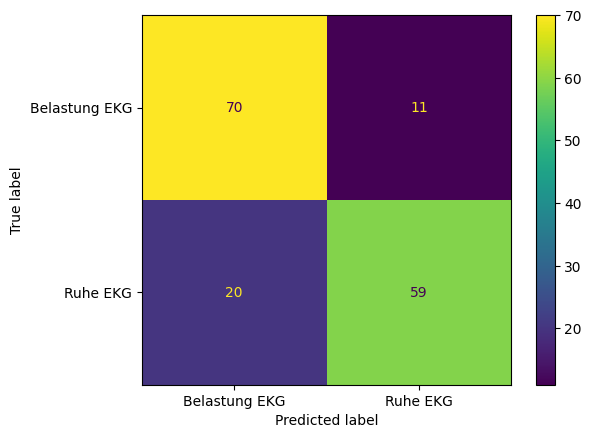

In [142]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_train, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()


In [143]:
# Weitere Fehlermetriken

from sklearn.metrics import classification_report

print(classification_report(y_train, y_pred))


               precision    recall  f1-score   support

Belastung EKG       0.78      0.86      0.82        81
     Ruhe EKG       0.84      0.75      0.79        79

     accuracy                           0.81       160
    macro avg       0.81      0.81      0.81       160
 weighted avg       0.81      0.81      0.81       160



Offensichtlich können wir in ca. 80% der Fälle korrekt zwischen Ruhe-EKG und Belastungs-EKG unterscheiden.

## Evaluieren des Modells auf den Testdaten

Zuletzt können wir das Modell auf den Testdaten evaluieren und den MSE berechnen. Hierzu nehmen wir das auf dem Trainingsdaten trainierte Modell und wenden es auf die Testdaten an. Dies stellt einen realistischeren Test dar, da wir das Modell auf Daten testen, die es noch nicht gesehen hat.

In der Regel sollte der Fehler auf den Testdaten höher sein als auf den Trainingsdaten, da das Modell auf den Trainingsdaten optimiert wurde.

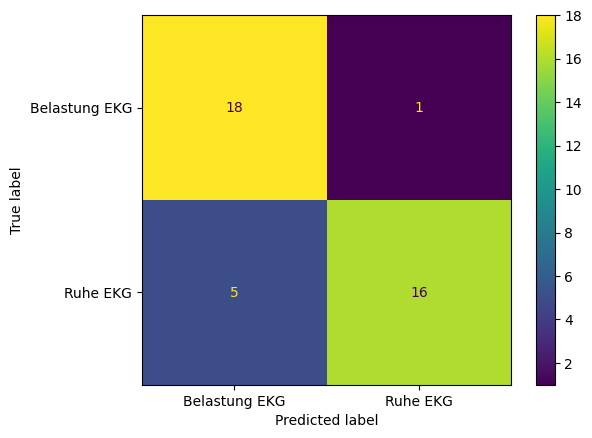

In [144]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()

## Weitere Modelle

Als nächstes könnten wir versuchen, das Modell zu verbessern, indem wir z.B. Polynomielle Features hinzufügen oder ein anderes Modell verwenden, z.B. Random Forest oder Gradient Boosting.

Hierbei ist aber darauf zu achten, dass wir Overfitting vermeiden, d.h. dass das Modell zu sehr auf die Trainingsdaten optimiert wird und auf den Testdaten schlechter abschneidet. Dies kann z.B. durch Regularisierung oder Cross-Validation verhindert werden.

### k-Nearest Neighbors (k-NN)

Ein weiteres Modell, das wir testen könnten, ist k-Nearest Neighbors (k-NN). Hierbei wird für jeden Datenpunkt die Distanz zu den k nächsten Nachbarn berechnet und die Klasse des Datenpunktes als die Klasse der Mehrheit der k nächsten Nachbarn bestimmt.

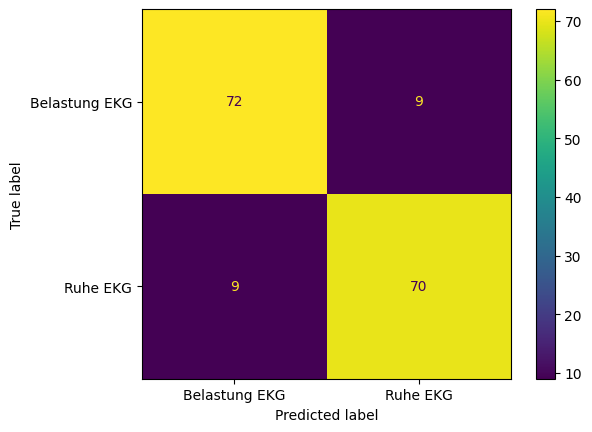

In [145]:
# Import knn
from sklearn.neighbors import KNeighborsClassifier

# Define the model with the number of neighbors
model = KNeighborsClassifier(n_neighbors=3)

# Fit the model

model.fit(X_train, y_train)

y_pred = model.predict(X_train)

cm = confusion_matrix(y_train, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()

Wir kommen auf leicht bessere F1-Scores auf den Trainingsdaten:

In [146]:
print(classification_report(y_train, y_pred))

               precision    recall  f1-score   support

Belastung EKG       0.89      0.89      0.89        81
     Ruhe EKG       0.89      0.89      0.89        79

     accuracy                           0.89       160
    macro avg       0.89      0.89      0.89       160
 weighted avg       0.89      0.89      0.89       160



Auf den Testdaten kommen wir auf einen geringfügig schlechteren F1-Score.

In [147]:
y_pred = grid_search.predict(X_test)

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

Belastung EKG       0.93      0.68      0.79        19
     Ruhe EKG       0.77      0.95      0.85        21

     accuracy                           0.82        40
    macro avg       0.85      0.82      0.82        40
 weighted avg       0.84      0.82      0.82        40



### Decision Tree

Alternativ nutzen wir einen Decision Tree, um die Daten zu klassifizieren. Hierbei wird der Datensatz rekursiv in Untergruppen aufgeteilt, bis die Datenpunkte in den Blättern eindeutig einer Klasse zugeordnet werden können.

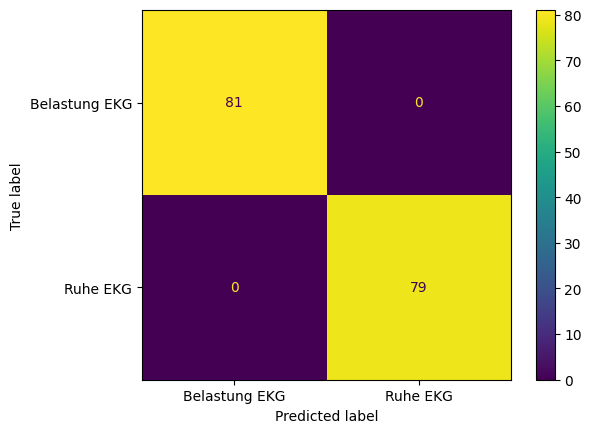

In [148]:
### Decision Tree

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_train)

cm = confusion_matrix(y_train, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()

In [149]:
print(classification_report(y_train, y_pred))

               precision    recall  f1-score   support

Belastung EKG       1.00      1.00      1.00        81
     Ruhe EKG       1.00      1.00      1.00        79

     accuracy                           1.00       160
    macro avg       1.00      1.00      1.00       160
 weighted avg       1.00      1.00      1.00       160



Hierbei können wir die Daten auf dem Trainingsdaten perfekt klassifizieren. Dies ist ein Hinweis darauf, dass wir ggf. in ein Overfitting Problem laufen. Allderings können wir auf den Testdaten auch eine gute Klassifikation erreichen.

               precision    recall  f1-score   support

Belastung EKG       0.71      0.79      0.75        19
     Ruhe EKG       0.79      0.71      0.75        21

     accuracy                           0.75        40
    macro avg       0.75      0.75      0.75        40
 weighted avg       0.75      0.75      0.75        40



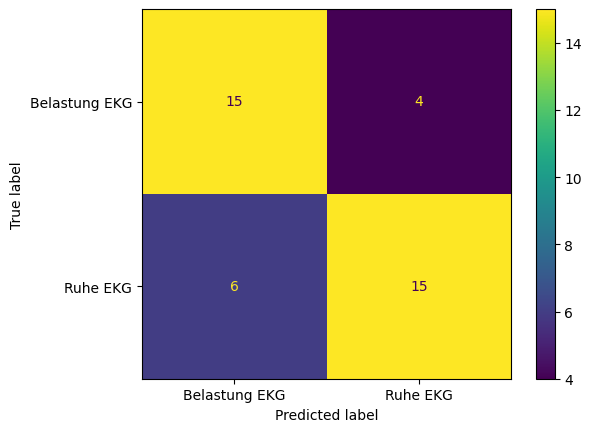

In [150]:
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()

print(classification_report(y_test, y_pred))


#### Visualisierung des Decision Trees

Wir können den Decision Tree auch visualisieren, um die Entscheidungsregeln besser zu verstehen. Hier sehen wir, dass der Baum aufgespannt wurde, bis jeder Datenpunkt eindeutig einer Klasse zugeordnet werden kann. Siehe Werte in in den Blättern (`value=[0, 1]` bedeutet, dass von der ersten Klasse 0, on der zweiten Klasse 1 Element in diese Kategorie fällt).

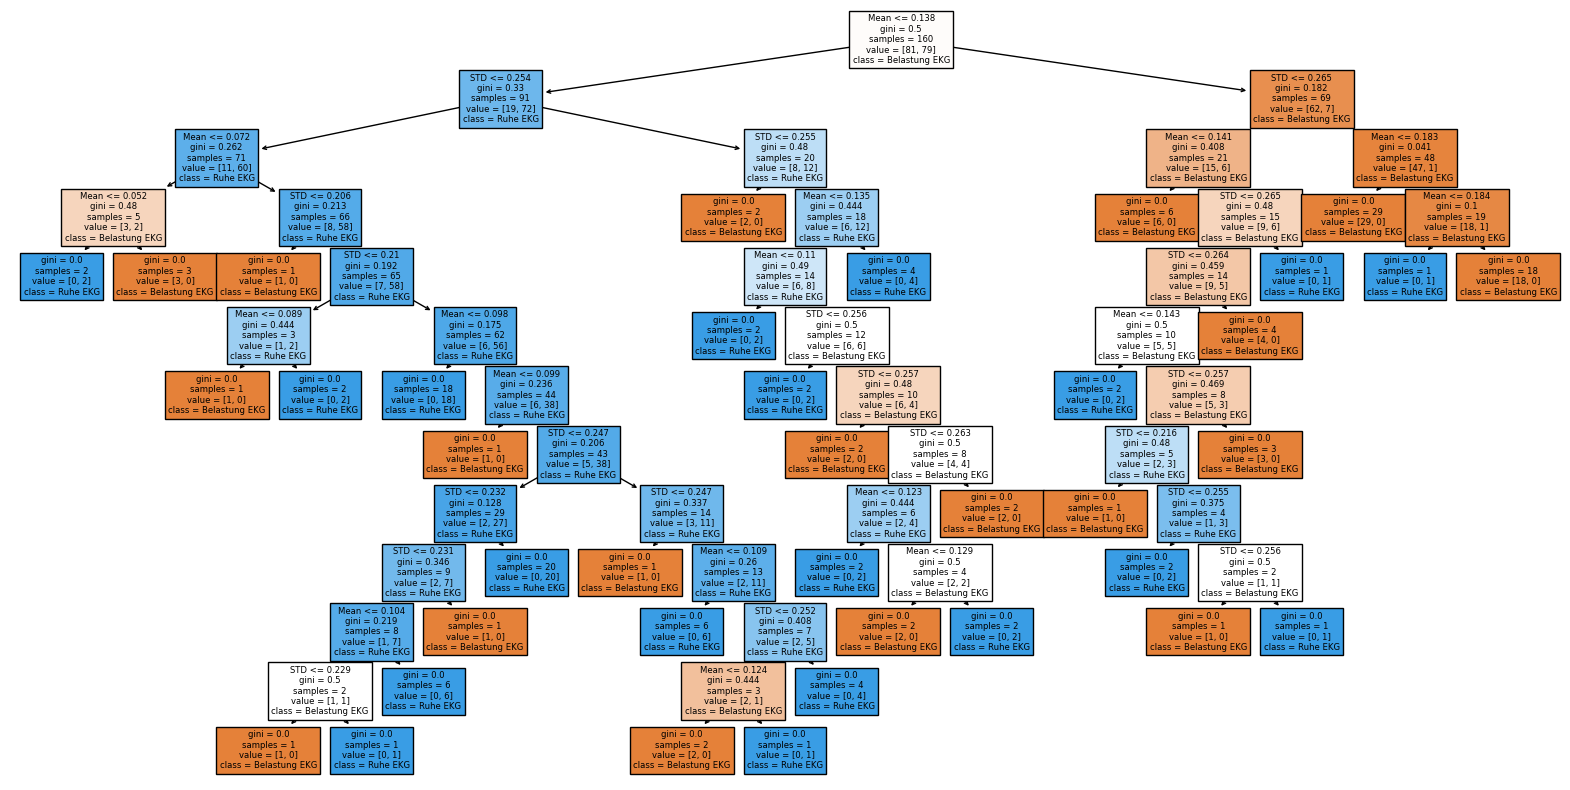

In [151]:
# Plot the decision tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(model, filled=True, feature_names=X.columns, class_names=model.classes_)
plt.show()

Für besser generalisierende Modelle können wir die Tiefe des Baumes beschränken oder Pruning verwenden. In der Folge haben wir im Training Set keine 100% Klassifikation, aber eine bessere Generalisierung auf den Testdaten.

               precision    recall  f1-score   support

Belastung EKG       0.90      0.77      0.83        81
     Ruhe EKG       0.79      0.91      0.85        79

     accuracy                           0.84       160
    macro avg       0.84      0.84      0.84       160
 weighted avg       0.85      0.84      0.84       160



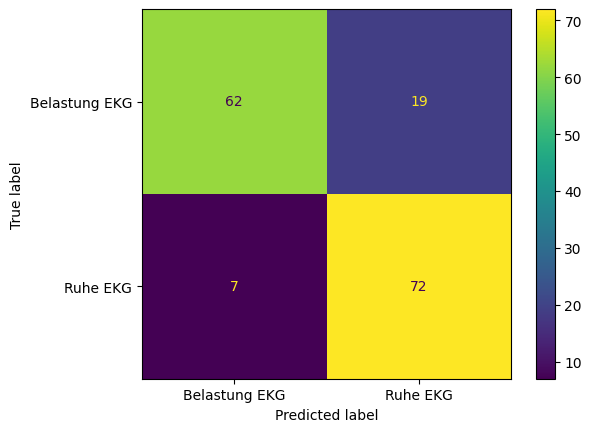

In [152]:
# Define a decision tree with a maximum depth of 2

model = DecisionTreeClassifier(max_depth=2)

model.fit(X_train, y_train)

y_pred = model.predict(X_train)

cm = confusion_matrix(y_train, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()

print(classification_report(y_train, y_pred))

Tätschlich erreichen wir hiermit im Testset eine bessere Klassifikation als mit dem tieferen Baum.

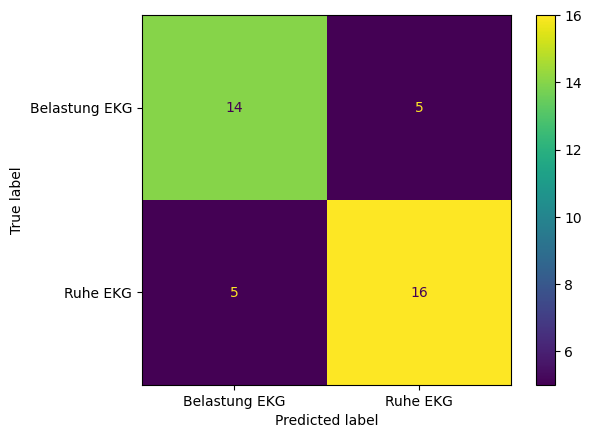

In [153]:
# Test Set

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

disp.plot()

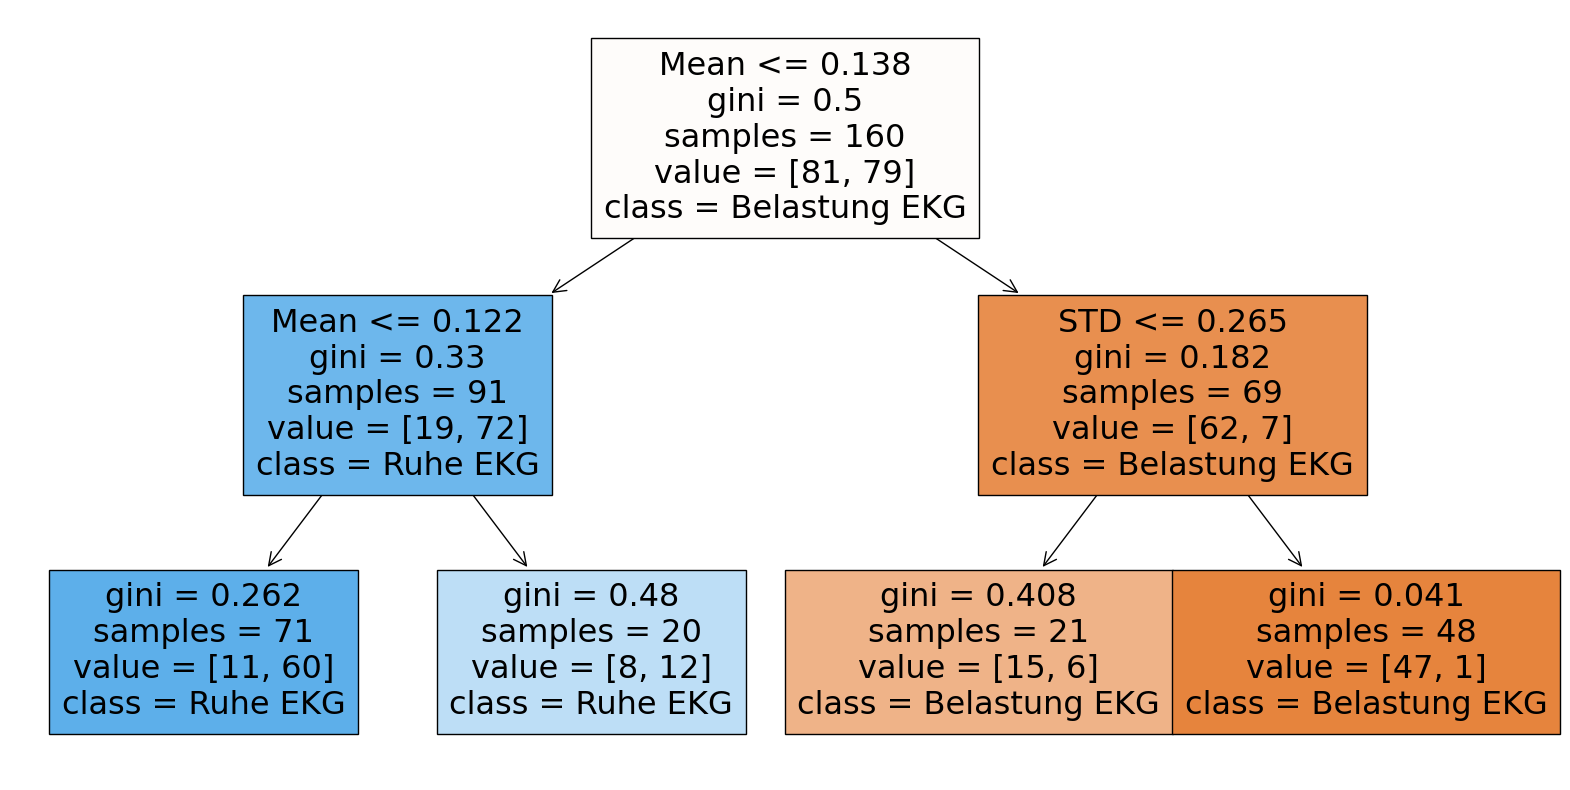

In [154]:
# Plot the decision tree

plt.figure(figsize=(20,10))

tree.plot_tree(model, filled=True, feature_names=X.columns, class_names=model.classes_)

plt.show()


## 🤓 Weitere Kniffe   

Nicht immer liegen die Daten so schön vor, wie in diesem Beispiel. In der Regel müssen wir die Daten erst aufbereiten, um sie für die Klassifikation zu verwenden. Hierzu können wir z.B. Kategoriale Variablen in numerische umwandeln, die Daten normalisieren oder standardisieren, um die Features auf eine vergleichbare Skala zu bringen.

### Erstellen von Dummy Variablen

Nicht alle Modelle können von Haus aus mit kategorialen Variablen (z.B. `Type`: `Ruhe EKG` vs. `Belastungs EKG`) umgehen. Hierzu können wir die Funktion `get_dummies()` aus dem Modul `pandas` verwenden.


In [159]:
df.head()

,EGK,Type,Mean,STD,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,...,Freq_90,Freq_91,Freq_92,Freq_93,Freq_94,Freq_95,Freq_96,Freq_97,Freq_98,Freq_99
0,"[1.0452403821099394, 1.0421752447207282, 1.035...",Ruhe EKG,0.121633,0.210865,61.759720,195.258097,283.019683,203.320485,184.854291,249.325614,...,23.909104,54.612808,23.848267,135.901525,163.263182,105.972713,90.613948,30.886371,25.491964,91.994923
1,"[1.1629829249380186, 1.1581694812787546, 1.146...",Ruhe EKG,0.140646,0.260412,39.365567,233.735586,289.788225,58.544874,36.466908,68.578035,...,48.064212,603.504076,50.700425,68.503268,81.919685,7.725875,14.660097,25.843257,7.106331,22.914575
2,"[1.128605448621482, 1.123413075442241, 1.11117...",Ruhe EKG,0.088686,0.239190,136.004201,168.234805,166.346702,61.612084,104.851645,67.380281,...,127.121069,88.634624,63.013574,324.722677,27.776219,82.082475,146.297379,51.178888,18.897645,82.055191
3,"[1.043730302149139, 1.0407825337096603, 1.0347...",Ruhe EKG,0.078706,0.217442,86.360026,195.921407,314.221805,134.447659,141.455721,210.643755,...,56.723068,95.960927,71.230662,192.865908,13.227622,140.464750,81.638067,93.502919,21.763904,16.378166
4,"[1.1321287758838947, 1.125699107133572, 1.1098...",Ruhe EKG,0.203906,0.226710,214.841635,109.638119,183.538773,125.544905,68.498290,96.904312,...,111.711328,54.459781,48.587835,40.572718,23.262292,34.000325,31.949804,20.076034,4.794255,18.455169


So können wir uns bei Bedarf die Dummy Variablen für die Variable `Type` erstellen:

In [160]:
pd.get_dummies(df['Type'])

,Belastung EKG,Ruhe EKG
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True
...,...,...
195,True,False
196,True,False
197,True,False
198,True,False


### Normalisieren der Daten

In unserem Fall sind die Abstände der Frequenzintensitäten bereits auf seiner Sinnvollen Skala. Häufig möchten wir die Daten aber normalisieren oder standardisieren, um die Features auf eine vergleichbare Skala zu bringen.

Hierbei helfen uns die Funktionen `MinMaxScaler` und `StandardScaler` aus dem Modul `sklearn.preprocessing` z.B., um die Daten von `Freq_1` auf eine Standardnormalverteilung zu transformieren.

In [167]:
# Standardize the Freq_1 column using the standard scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Freq_1'] = scaler.fit_transform(df[['Freq_1']])

df.head()


,EGK,Type,Mean,STD,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,...,Freq_90,Freq_91,Freq_92,Freq_93,Freq_94,Freq_95,Freq_96,Freq_97,Freq_98,Freq_99
0,"[1.0452403821099394, 1.0421752447207282, 1.035...",Ruhe EKG,0.121633,0.210865,-0.689087,195.258097,283.019683,203.320485,184.854291,249.325614,...,23.909104,54.612808,23.848267,135.901525,163.263182,105.972713,90.613948,30.886371,25.491964,91.994923
1,"[1.1629829249380186, 1.1581694812787546, 1.146...",Ruhe EKG,0.140646,0.260412,-0.904146,233.735586,289.788225,58.544874,36.466908,68.578035,...,48.064212,603.504076,50.700425,68.503268,81.919685,7.725875,14.660097,25.843257,7.106331,22.914575
2,"[1.128605448621482, 1.123413075442241, 1.11117...",Ruhe EKG,0.088686,0.239190,0.023910,168.234805,166.346702,61.612084,104.851645,67.380281,...,127.121069,88.634624,63.013574,324.722677,27.776219,82.082475,146.297379,51.178888,18.897645,82.055191
3,"[1.043730302149139, 1.0407825337096603, 1.0347...",Ruhe EKG,0.078706,0.217442,-0.452841,195.921407,314.221805,134.447659,141.455721,210.643755,...,56.723068,95.960927,71.230662,192.865908,13.227622,140.464750,81.638067,93.502919,21.763904,16.378166
4,"[1.1321287758838947, 1.125699107133572, 1.1098...",Ruhe EKG,0.203906,0.226710,0.781015,109.638119,183.538773,125.544905,68.498290,96.904312,...,111.711328,54.459781,48.587835,40.572718,23.262292,34.000325,31.949804,20.076034,4.794255,18.455169


In [170]:
# Normalize the Freq_2 column using the MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['Freq_2'] = scaler.fit_transform(df[['Freq_2']])

df.head()

,EGK,Type,Mean,STD,Freq_1,Freq_2,Freq_3,Freq_4,Freq_5,Freq_6,...,Freq_90,Freq_91,Freq_92,Freq_93,Freq_94,Freq_95,Freq_96,Freq_97,Freq_98,Freq_99
0,"[1.0452403821099394, 1.0421752447207282, 1.035...",Ruhe EKG,0.121633,0.210865,-0.689087,0.142184,283.019683,203.320485,184.854291,249.325614,...,23.909104,54.612808,23.848267,135.901525,163.263182,105.972713,90.613948,30.886371,25.491964,91.994923
1,"[1.1629829249380186, 1.1581694812787546, 1.146...",Ruhe EKG,0.140646,0.260412,-0.904146,0.198795,289.788225,58.544874,36.466908,68.578035,...,48.064212,603.504076,50.700425,68.503268,81.919685,7.725875,14.660097,25.843257,7.106331,22.914575
2,"[1.128605448621482, 1.123413075442241, 1.11117...",Ruhe EKG,0.088686,0.239190,0.023910,0.102425,166.346702,61.612084,104.851645,67.380281,...,127.121069,88.634624,63.013574,324.722677,27.776219,82.082475,146.297379,51.178888,18.897645,82.055191
3,"[1.043730302149139, 1.0407825337096603, 1.0347...",Ruhe EKG,0.078706,0.217442,-0.452841,0.143160,314.221805,134.447659,141.455721,210.643755,...,56.723068,95.960927,71.230662,192.865908,13.227622,140.464750,81.638067,93.502919,21.763904,16.378166
4,"[1.1321287758838947, 1.125699107133572, 1.1098...",Ruhe EKG,0.203906,0.226710,0.781015,0.016213,183.538773,125.544905,68.498290,96.904312,...,111.711328,54.459781,48.587835,40.572718,23.262292,34.000325,31.949804,20.076034,4.794255,18.455169
